In [1]:
%pip install kagglehub
%pip install pandas scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]/4 [kagglesdk]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 54.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 44.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 56.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 52.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]3/14 [seaborn]ib]n]

[notice] A new release of pip is available: 

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")
csv_path = os.path.join(path, "loan.csv")

# Only load the first 1.4 million rows (out of 2.26 million)
#loan_df = pd.read_csv(csv_path, nrows=1400000)

# retreive all column names
cols = pd.read_csv(csv_path, nrows=0).columns

# column to be dropped, comments are missing percentage
cols_to_drop = ['id',   # 100%
                'member_id',   # 100%
                'url',   # 100%
                'desc',   # 94%
                'mths_since_last_delinq',  # 51%
                'mths_since_last_record',  # 84%
                'next_pymnt_d',   # 58%
                'mths_since_last_major_derog',   # 74%
                'annual_inc_joint',   # 95%
                'dti_joint',   # 95%
                'verification_status_joint',   # 95%
                'open_acc_6m',   # 38%
                'open_act_il',   # 38%
                'open_il_12m',   # 38%
                'open_il_24m',   # 38%
                'mths_since_rcnt_il',   # 40%
                #'total_bal_il',   # 38%
                #'il_util',   # 47%
                'open_rv_12m',   # 38%
                'open_rv_24m',   # 38%
                'max_bal_bc',   # 38%
                #'all_util',   # 38%
                'inq_fi',   # 38%
                'total_cu_tl',   # 38%
                #'inq_last_12m',   # 38%
                'mths_since_recent_bc_dlq',  # 77%
                'mths_since_recent_revol_delinq',  # 67%
                'revol_bal_joint',  # 95%
                'sec_app_earliest_cr_line',  # 95%
                'sec_app_inq_last_6mths',   # 95%
                'sec_app_mort_acc',   # 95%
                'sec_app_open_acc',   # 95%
                'sec_app_revol_util',   # 95%
                'sec_app_open_act_il',  # 95%
                'sec_app_num_rev_accts',  # 95%
                'sec_app_chargeoff_within_12_mths',   # 95%
                'sec_app_collections_12_mths_ex_med',   # 95%
                'sec_app_mths_since_last_major_derog',  # 98%
                'hardship_type',   # 100%
                'hardship_reason',  # 100%
                'hardship_status',  # 100%
                'deferral_term',   # 100%
                'hardship_amount',  # 100%
                'hardship_start_date',  # 100%
                'hardship_end_date',   # 100%
                'payment_plan_start_date',   # 100%
                'hardship_length',   # 100%
                'hardship_dpd',  # 100%
                'hardship_loan_status',   # 100%
                'orig_projected_additional_accrued_interest',  # 100%
                'hardship_payoff_balance_amount',   # 100%
                'hardship_last_payment_amount',   # 100%
                'debt_settlement_flag_date',   # 99%
                'settlement_status',   # 99%
                'settlement_date',   # 99%
                'settlement_amount',   # 99%
                'settlement_percentage',   # 99%
                'settlement_term',  # 99%
                
                # Variables irrelevant for default prediction
                #'collection_recovery_fee',
                #'recoveries',
                'last_credit_pull_d',
                'last_pymnt_amnt',
                'last_pymnt_d',
                'out_prncp',
                'out_prncp_inv',
                'total_pymnt',
                'total_pymnt_inv',
                'total_rec_int',
                'total_rec_late_fee',
                #'total_rec_prncp',

                # add more irrelevant columns (by Kasem)
                'policy_code',
                'tot_coll_amt',
                #'total_rev_hi_lim',  # correlated with revol_util
                #'avg_cur_bal',
                #'bc_open_to_buy',
                'mo_sin_old_il_acct',
                'mo_sin_rcnt_rev_tl_op',
                'mo_sin_rcnt_tl',
                'mths_since_recent_inq',
                'num_actv_bc_tl',

                #ashish
                'funded_amnt',      # post-application, leakage
                'funded_amnt_inv',  # post-application, leakage
                #'installment',      # derived from loan_amnt + int_rate + term, redundant
                'grade',            # multicollinesrity with sub-grade
                'issue_d',          # will not be available at prediction time
                'pymnt_plan',       # post-default indicator, pure leakage
                'title',            # free-text, redundant with purpose
                'zip_code',         # redundant with addr_state, too granular
                
                #prerna
                'hardship_flag',         # Post-loan hardship event (data leakage)
                'debt_settlement_flag',  # Post-default outcome indicator (data leakage)
                'disbursement_method',   # Operational variable, not related to credit risk
                'num_sats',              # Raw count; percentage version is more informative
                'num_bc_tl',             # Weak standalone signal; redundant with other credit counts
                'num_il_tl',             # Installment count adds little predictive value
                'num_op_rev_tl',         # Highly correlated with other account count variables
                'num_rev_accts',         # Redundant credit depth measure
                'total_bc_limit'         # Redundant with overall credit limit (tot_hi_cred_lim)
                ]

# columns to keep
cols_to_keep = [col for col in cols if col not in cols_to_drop]

# load data
loan_df = pd.read_csv(csv_path, usecols=cols_to_keep)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 339M/339M [00:04<00:00, 87.3MB/s] 

Extracting files...


In [3]:
# create index column
loan_df['index'] = loan_df.index

In [4]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 60 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   term                        str    
 2   int_rate                    float64
 3   installment                 float64
 4   sub_grade                   str    
 5   emp_title                   str    
 6   emp_length                  str    
 7   home_ownership              str    
 8   annual_inc                  float64
 9   verification_status         str    
 10  loan_status                 str    
 11  purpose                     str    
 12  addr_state                  str    
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  earliest_cr_line            str    
 16  inq_last_6mths              float64
 17  open_acc                    float64
 18  pub_rec                     float64
 19  revol_bal                   int6

In [5]:
# Check for columns with large amount of missing values
missing = loan_df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

il_util                       1068850
all_util                       866348
inq_last_12m                   866130
total_bal_il                   866129
emp_title                      166969
num_tl_120dpd_2m               153657
emp_length                     146907
bc_util                         76071
percent_bc_gt_75                75379
bc_open_to_buy                  74935
mths_since_recent_bc            73412
pct_tl_nvr_dlq                  70431
avg_cur_bal                     70346
mo_sin_old_rev_tl_op            70277
total_il_high_credit_limit      70276
num_actv_rev_tl                 70276
num_accts_ever_120_pd           70276
num_rev_tl_bal_gt_0             70276
num_tl_30dpd                    70276
total_rev_hi_lim                70276
num_tl_90g_dpd_24m              70276
num_tl_op_past_12m              70276
tot_hi_cred_lim                 70276
tot_cur_bal                     70276
num_bc_sats                     58590
mort_acc                        50030
acc_open_pas

In [6]:
# change string cols to categorical type

# list of column names to change to categorical type
to_cat_list = ['application_type', 'home_ownership', 'verification_status', 
               'purpose', 'initial_list_status']
loan_df[to_cat_list] = loan_df[to_cat_list].astype('category')

In [7]:
# change cols to numeric dtype
loan_df['term'] = loan_df['term'].str.strip().str.replace(' months', '').astype(int)
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8,
    '9 years': 9, '10+ years': 10
}
loan_df['emp_length'] = loan_df['emp_length'].map(emp_length_map)
loan_df['emp_length'] = loan_df['emp_length'].fillna(loan_df['emp_length'].median())

# Create new binary variable for employment based on employment title
loan_df["Employed"] = loan_df["emp_title"].notna().astype(int)
loan_df["emp_title"] = loan_df["emp_title"].fillna("Unemployed")

# Convert to credit age in years
from datetime import datetime
loan_df['earliest_cr_line'] = pd.to_datetime(loan_df['earliest_cr_line'], format='%b-%Y')
loan_df['credit_age_years'] = (pd.Timestamp.now() - loan_df['earliest_cr_line']).dt.days / 365
loan_df.drop('earliest_cr_line', axis=1, inplace=True)

In [8]:
loan_df["loan_status"].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [9]:
small_null_cols = [col for col in loan_df.columns if 0 < loan_df[col].isnull().sum() <= 2000]
print(small_null_cols)

loan_df = loan_df.dropna(subset=small_null_cols)
print(loan_df.shape) 

['annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies', 'tax_liens', 'credit_age_years']
(2255820, 61)


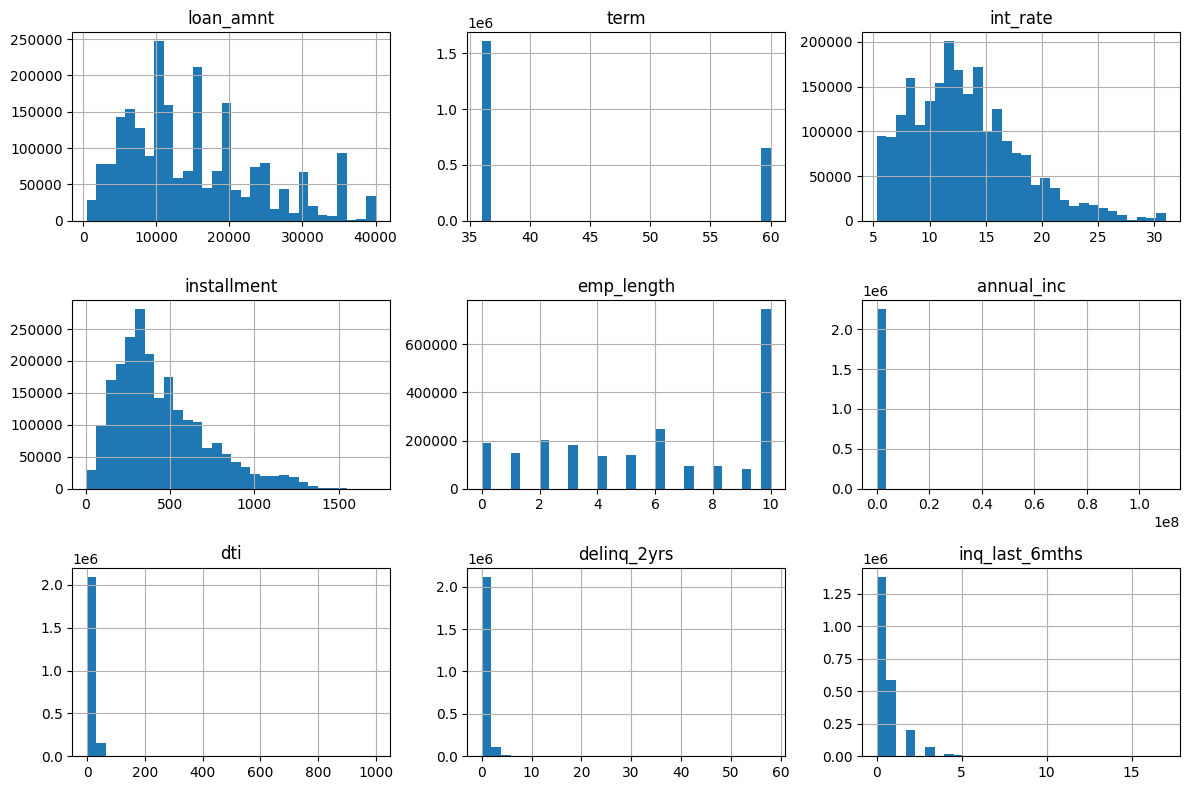

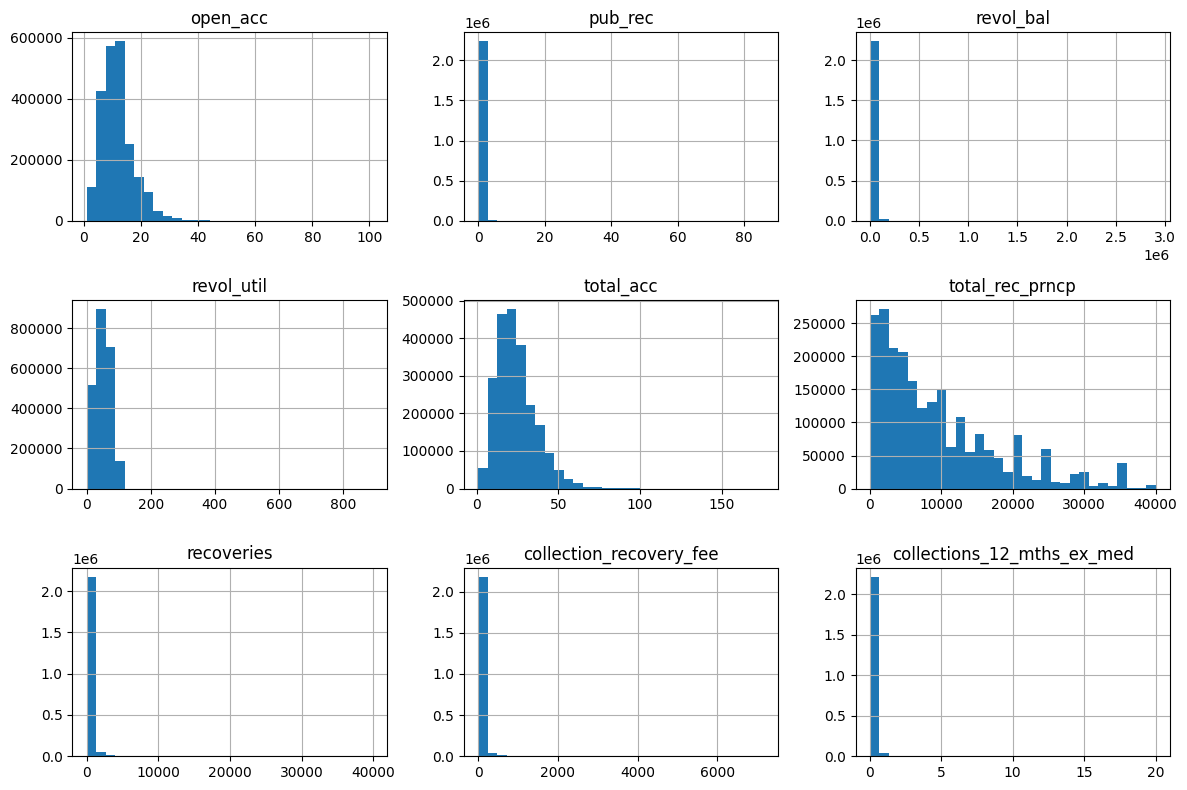

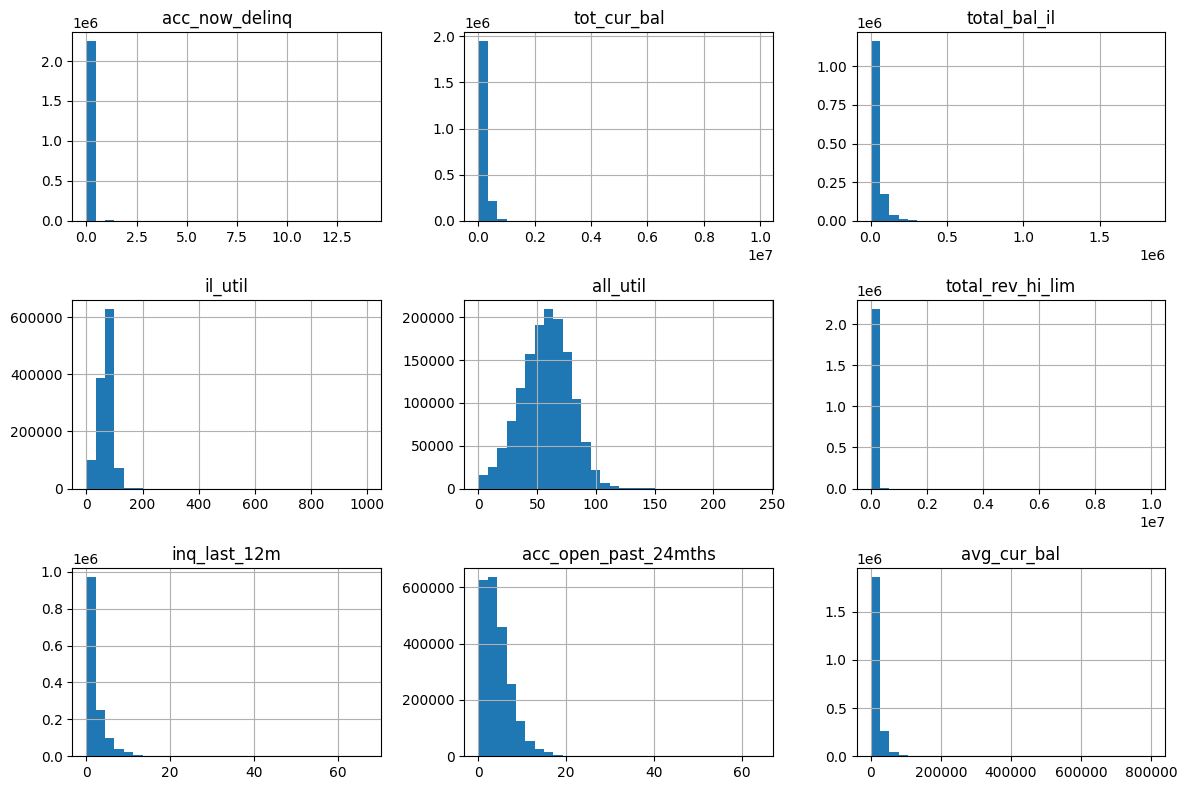

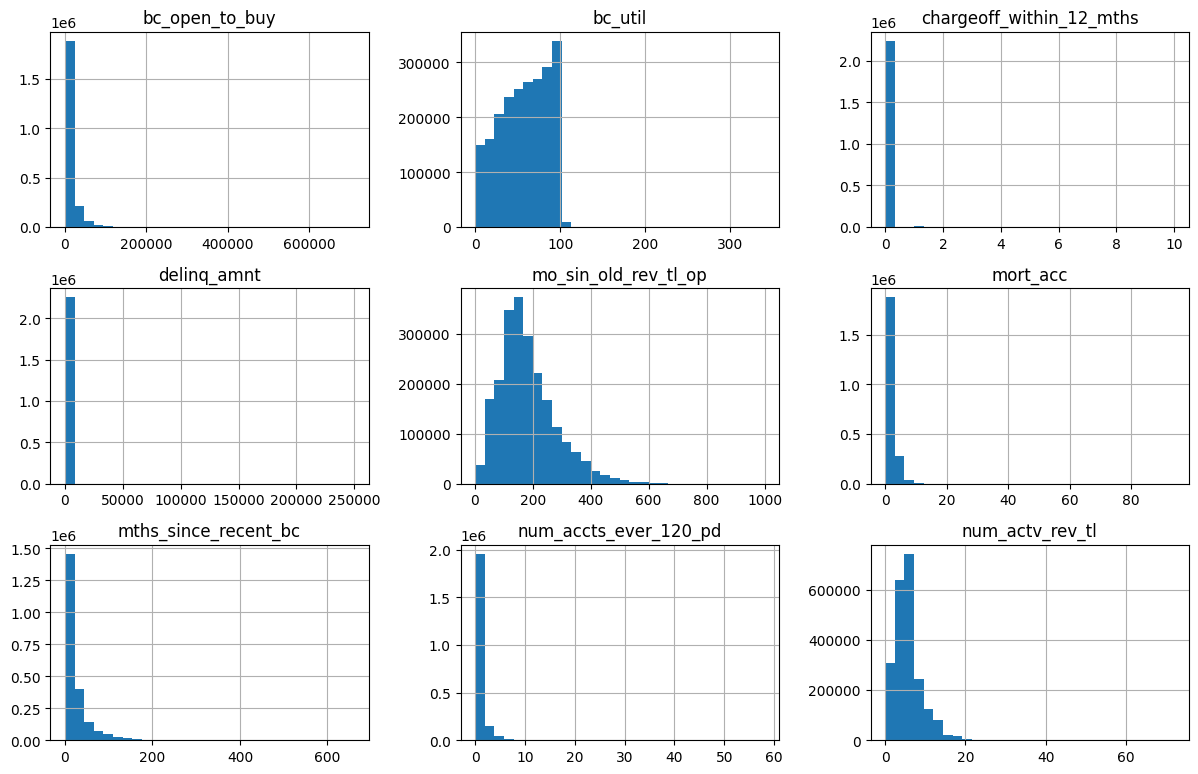

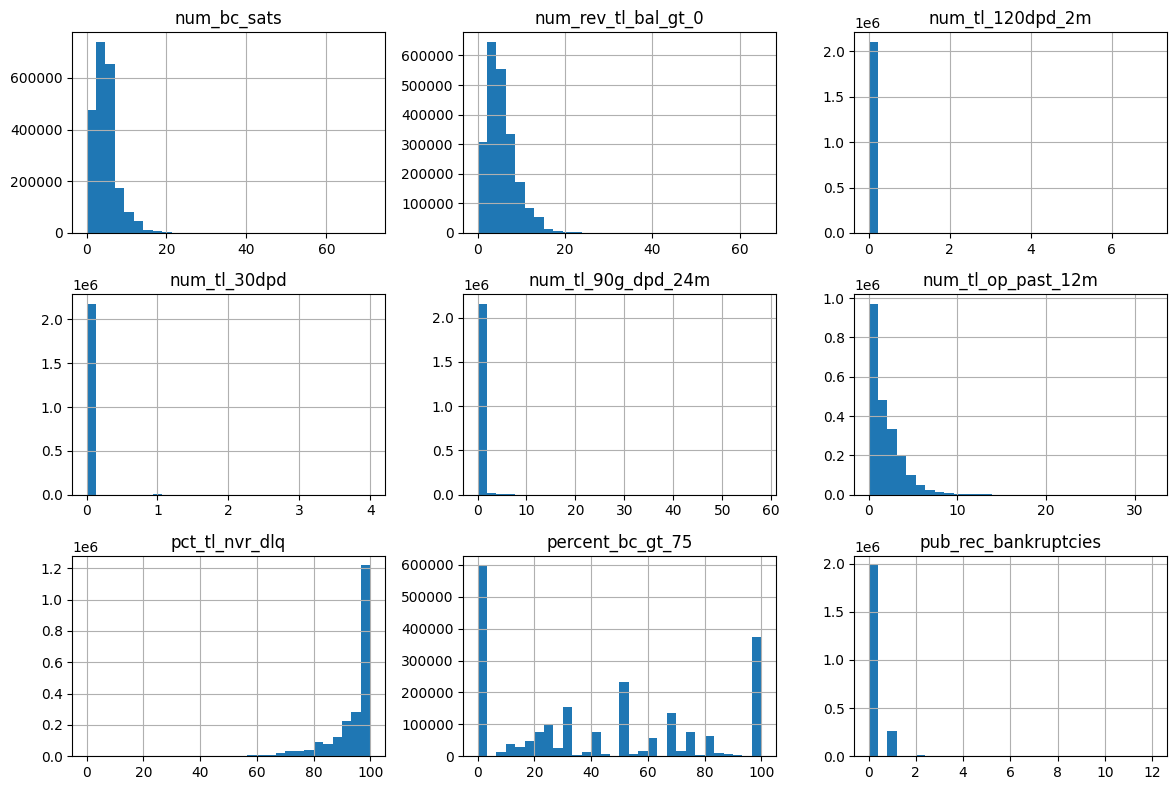

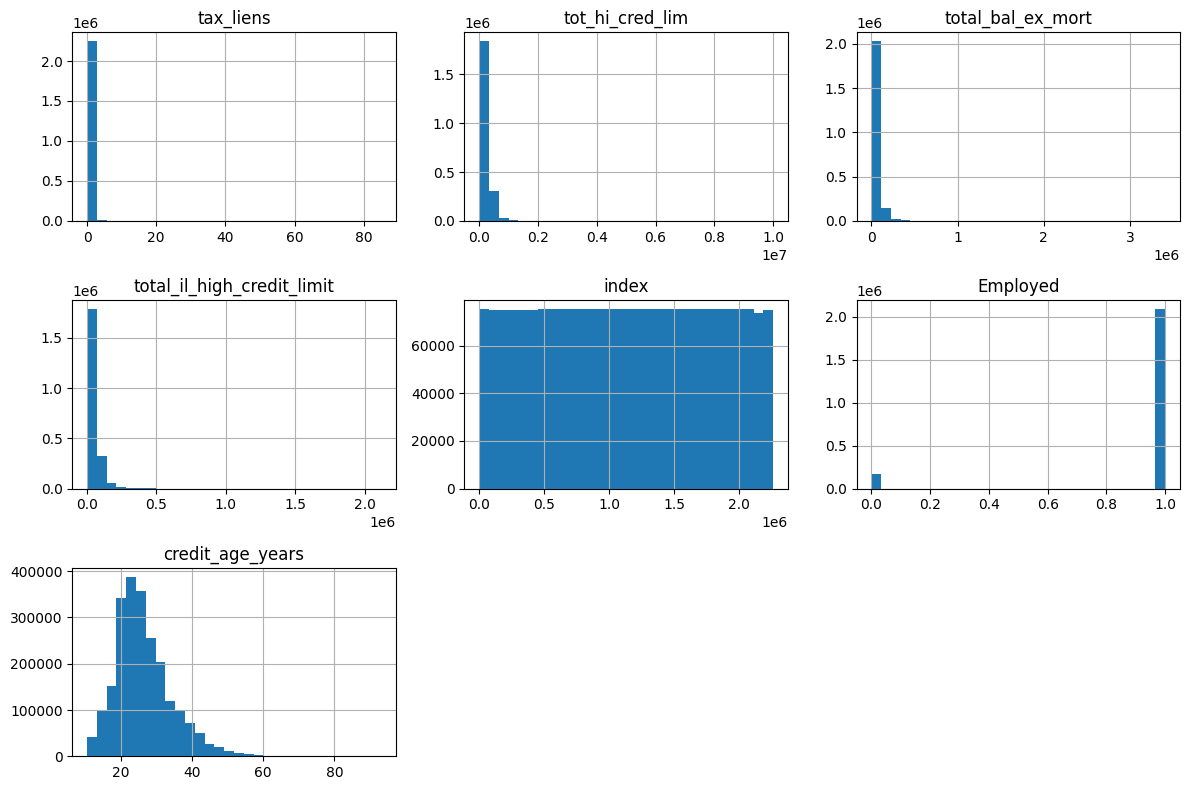

In [10]:
# plot histogram for all numerical columns
import matplotlib.pyplot as plt


cols = loan_df.select_dtypes(include='number').columns
batch_size = 9  # 3x3 grid per figure

for i in range(0, len(cols), batch_size):
    batch = cols[i:i+batch_size]
    loan_df[batch].hist(figsize=(12, 8), bins=30)
    plt.tight_layout()
    plt.show()

In [11]:
# Check outlier inc annually income -- imp factor while lending
print(loan_df['annual_inc'].describe())
print(loan_df['annual_inc'].quantile(0.999))

# Cap at 99.9th percentile
cap = loan_df['annual_inc'].quantile(0.999)
loan_df['annual_inc'] = loan_df['annual_inc'].clip(upper=cap)

count    2.255820e+06
mean     7.804968e+04
std      1.127283e+05
min      0.000000e+00
25%      4.600000e+04
50%      6.500000e+04
75%      9.300000e+04
max      1.100000e+08
Name: annual_inc, dtype: float64
600000.0


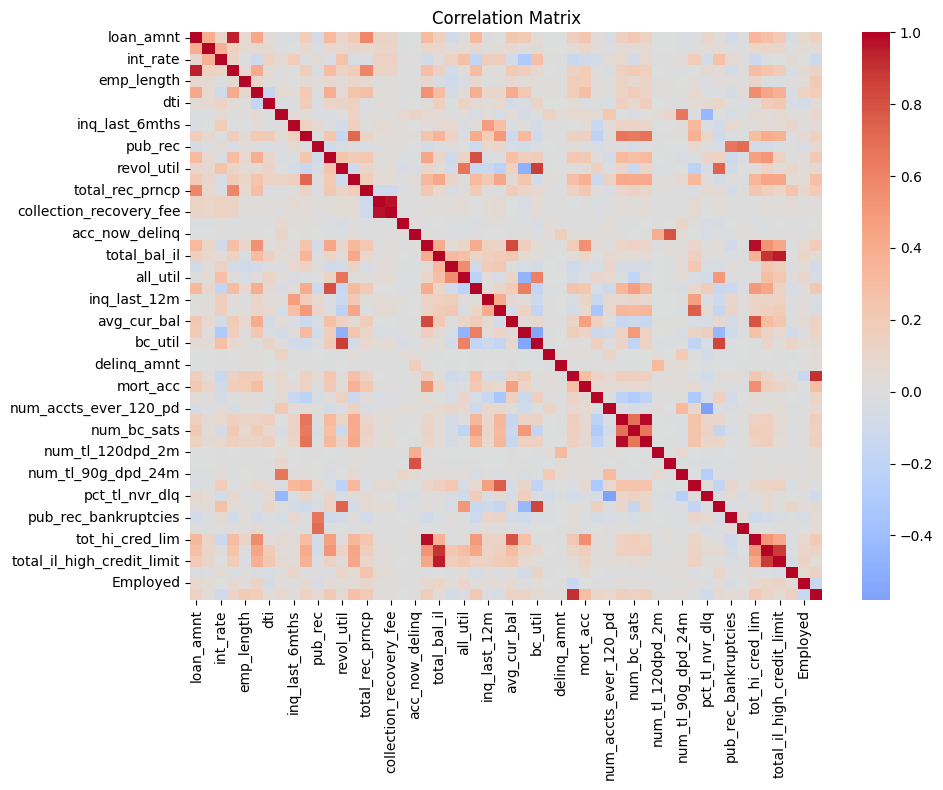

In [12]:
# heatmap for correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(loan_df.select_dtypes('number').corr(), cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
# correlation table
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
loan_df.select_dtypes('number').corr()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_rec_prncp,recoveries,collection_recovery_fee,collections_12_mths_ex_med,acc_now_delinq,tot_cur_bal,total_bal_il,il_util,all_util,total_rev_hi_lim,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_rev_tl_op,mort_acc,mths_since_recent_bc,num_accts_ever_120_pd,num_actv_rev_tl,num_bc_sats,num_rev_tl_bal_gt_0,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_il_high_credit_limit,index,Employed,credit_age_years
loan_amnt,1.000000,0.393707,0.098187,0.945597,0.076278,0.423920,0.043339,-0.009180,-0.027218,0.182183,-0.058977,0.317310,0.099134,0.199655,0.578352,0.121139,0.116146,-0.021891,-0.000517,0.310470,0.150682,-0.088004,0.002824,0.328658,0.009383,-0.000962,0.227815,0.205408,0.048399,-0.003787,0.000814,0.165557,0.219145,0.036324,-0.053487,0.149117,0.212476,0.148492,-0.001808,0.000915,-0.023502,-0.026831,0.089420,0.020824,-0.083698,0.007516,0.335273,0.276459,0.208666,-0.048171,0.074734,0.142073
term,0.393707,1.000000,0.372711,0.139007,0.053495,0.078049,0.058125,-0.009132,-0.000676,0.074688,-0.017659,0.083394,0.067266,0.095760,0.085969,0.108235,0.101077,-0.009940,-0.000038,0.111081,0.081732,0.022610,0.047812,0.069089,0.024359,0.026246,0.084166,0.015239,0.051414,-0.002230,-0.000897,0.047691,0.102998,0.021005,-0.018773,0.055570,0.049460,0.055882,-0.001690,0.000648,-0.011019,0.006933,0.042818,0.047633,-0.011675,-0.009024,0.108622,0.107230,0.091745,-0.006994,0.049535,0.044653
int_rate,0.098187,0.372711,1.000000,0.124009,-0.009609,-0.106355,0.124772,0.058817,0.189861,-0.010162,0.053506,-0.028722,0.262559,-0.040800,-0.026473,0.145043,0.134616,0.018336,0.015566,-0.085546,0.035310,0.143990,0.289949,-0.181654,0.166327,0.172428,-0.083728,-0.297285,0.277094,0.014184,0.004854,-0.133578,-0.090003,-0.075505,0.051768,0.082859,-0.060868,0.082741,0.006077,0.012771,0.033398,0.182081,-0.079232,0.271852,0.056812,0.013936,-0.123947,0.007090,-0.001588,0.058744,-0.004014,-0.103110
installment,0.945597,0.139007,0.124009,1.000000,0.063624,0.409413,0.044673,0.002161,-0.001726,0.171410,-0.047209,0.303329,0.120984,0.178415,0.597500,0.119013,0.114335,-0.017512,0.002135,0.277661,0.138837,-0.081379,0.028551,0.297866,0.026137,0.017550,0.199602,0.167840,0.074082,-0.001034,0.001955,0.141652,0.184471,0.018298,-0.043110,0.156072,0.204663,0.155189,-0.000422,0.002986,-0.017052,-0.004193,0.070350,0.044023,-0.075195,0.014280,0.299225,0.258580,0.191308,-0.037413,0.065156,0.122588
emp_length,0.076278,0.053495,-0.009609,0.063624,1.000000,0.088810,0.014629,0.021915,-0.000458,0.051099,0.030535,0.085098,0.035403,0.104361,0.073646,0.010743,0.010537,-0.006411,0.008512,0.097495,-0.041950,-0.095496,-0.048612,0.084529,-0.005950,0.023481,0.081882,0.026986,0.031023,0.009152,0.001794,0.193115,0.180294,0.037354,0.009023,0.121608,0.069192,0.122540,0.001797,0.007990,-0.001275,0.023055,-0.019211,0.028540,0.023622,0.014957,0.112462,-0.009716,-0.025982,0.003307,0.025909,0.201850
annual_inc,0.423920,0.078049,-0.106355,0.409413,0.088810,1.000000,-0.164588,0.056509,0.043872,0.205046,-0.005926,0.393449,0.061540,0.250225,0.292838,0.022439,0.022589,-0.006681,0.015656,0.533395,0.297481,-0.058069,0.025745,0.389111,0.099862,0.087404,0.401329,0.221695,0.011486,0.010366,0.008506,0.186828,0.293162,0.028381,0.019320,0.124897,0.189526,0.123013,0.006114,0.014410,0.009104,0.074668,-0.009833,-0.006660,-0.059468,0.052976,0.557601,0.438880,0.377516,-0.031453,0.123460,0.179968
dti,0.043339,0.058125,0.124772,0.044673,0.014629,-0.164588,1.000000,-0.012242,-0.011787,0.186268,-0.026205,0.102500,0.115122,0.147298,-0.028945,0.021091,0.021912,-0.007085,-0.000169,0.021360,0.155481,-0.012728,0.124230,0.061459,0.025104,0.084503,-0.056011,-0.036011,0.117817,-0.003360,-0.003698,0.041188,-0.009563,0.

In [ ]:
# save file
#loan_df.to_csv('loan_data.csv', index=False)

# csv file link
# https://drive.google.com/file/d/1ewIyvaTB1T_BVNM5CYNTXrIpPv9kJjK3/view?usp=sharing

In [13]:
# The following drive has cleaned loan_default dataset
# https://drive.google.com/drive/folders/1O-em9ZJIMIjs-PXUTE1hzbpjNUhYRsW2?usp=sharing